# Simple Guide (once setup!)

## [Pandeia Input Documentation](https://jwst-docs.stsci.edu/jwst-exposure-time-calculator-overview/jwst-etc-pandeia-engine-tutorial/pandeia-configuration-dictionaries#gsc.tab=0)

In [1]:
# Pandeia reference data
import os
os.environ["pandeia_refdata"] = "./ref_data/pandeia_data-2025.7-jwst"
os.environ["PYSYN_CDBS"] = "./ref_data/hlsp_reference-atlases_hst_multi_everything_multi_v16_sed/grp/redcat/trds"

# Exposure time calculator
from pandeia.engine.calc_utils import build_default_calc
from pandeia.engine.perform_calculation import perform_calculation

### Technically, only a few input parameters are required

In [2]:
# Required parameters
telescope = "jwst"
instrument = "nircam"
mode = "lw_imaging"

# Set default parameters
calc = build_default_calc(telescope, instrument, mode)

# Perform calculation
report = perform_calculation(calc)

## [Pandeia Report Documentation](https://jwst-docs.stsci.edu/jwst-exposure-time-calculator-overview/jwst-etc-pandeia-engine-tutorial/pandeia-reports#gsc.tab=0)

### Some Pandeia Outputs ...

In [3]:
# Exposure information
print(report['information']['exposure_specification'])
print('\n')

# Coordinate transformation
print(report['transform'])
print('\n')

# Scalar results
print(report['scalar'])
print('\n')

{'webapp': True, 'readout_pattern': 'shallow4', 'subarray': 'full', 'ngroup': 10, 'nint': 1, 'nexp': 4, 'tframe': 10.73677, 'tfffr': 0.0, 'nframe': 4, 'ndrop2': 1, 'nprerej': 0, 'npostrej': 0, 'nreset1': 0, 'nreset2': 1, 'ndrop1': 0, 'ndrop3': 0, 'frame0': False, 'nsample': 1, 'nsample_skip': 0, 'tgroup': 53.68385, 'measurement_time': 483.15465000000006, 'exposure_time': 526.10173, 'saturation_time': 526.10173, 'duty_cycle': 1.0, 'total_exposure_time': 2104.40692, 'exposures': 4, 'total_integrations': 4, 'photon_collect': 2104.40692, 'nramps': 4, 'all_dithers_time': 2104.40692}


{'x_refpix': 0, 'x_refval': np.float64(-1.953), 'x_max': np.float64(1.9845000000000002), 'x_min': np.float64(-1.9845000000000002), 'x_step': np.float64(0.063), 'x_size': 63, 'y_refpix': 0, 'y_refval': np.float64(1.953), 'y_max': np.float64(1.9845000000000002), 'y_min': np.float64(-1.9845000000000002), 'y_step': np.float64(-0.063), 'y_size': 63, 'wave_refpix': 0, 'wave_refval': np.float64(2.37551), 'wave_max': 

### Other report outputs include...

`1d` results (spectra, wave, flux)

`2d` results (image of object)

`3d` results (IFU)

`input` (the input calculation object)

## Of course, we can configure the input a lot more!

### Readout Pattern Docs
- [NIRcam](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-instrumentation/nircam-detector-overview/nircam-detector-readout-patterns#gsc.tab=0)
- [NIRSpec](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-instrumentation/nirspec-detectors/nirspec-detector-readout-modes-and-patterns#gsc.tab=0)

### Recommended Strategies
- [NIRCam](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-observing-strategies/nircam-imaging-recommended-strategies#gsc.tab=0) -- Single integration time should be less than 1,000 seconds!

In [4]:
# Telescope
telescope = 'jwst'
instrument = 'nircam'
mode = 'lw_imaging'
filter = 'f277w'
readout_pattern = "medium8"

# Exposure parameters 
ngroups = 10 # different min/max depending on readout pattern
nints = 2 # min=1, max=10 (always I think)
nexps = 4 # number of exposures (dithers)

# Flux parameters
flux_unit = 'abmag' # flux unit
magnitude = 22.0 # units above
geometry = 'point' # more options in docs
sed = 'flat' # more options in docs
sed_unit = 'fnu' # 'fnu', 'flam', more options in docs

# Set default calculation
calc = build_default_calc(telescope, instrument, mode)

# Instrument
calc['configuration']['instrument']['filter'] = filter

# Detector settings
calc['configuration']['detector']['readout_pattern'] = readout_pattern
calc['configuration']['detector']['ngroup'] = ngroups
calc['configuration']['detector']['nint'] = nints
calc['configuration']['detector']['nexp'] = nexps

# Source settings
scene = calc['scene'][0]
scene['spectrum']['normalization'] = {}
scene['spectrum']['normalization']['type'] = 'jwst'
scene['spectrum']['normalization']['bandpass'] = 'nircam,lw_imaging,f444w'
scene['spectrum']['normalization']['norm_flux'] = magnitude
scene['spectrum']['normalization']['norm_fluxunit'] = flux_unit
scene['shape']['geometry'] = geometry
scene['spectrum']['sed']['sed_type'] = sed
scene['spectrum']['sed']['unit'] = sed_unit

# Background
calc['background_level'] = 'low'  # 'low', 'medium', 'high', can define custom target at RA/Dec

# Perform calculation
report = perform_calculation(calc)

## A more detailed look at outputs

Total Exposure Time: 8460.57476 seconds
Single Exposure Time: 2115.14369 seconds
Single Integration Time: 1057.571845 seconds




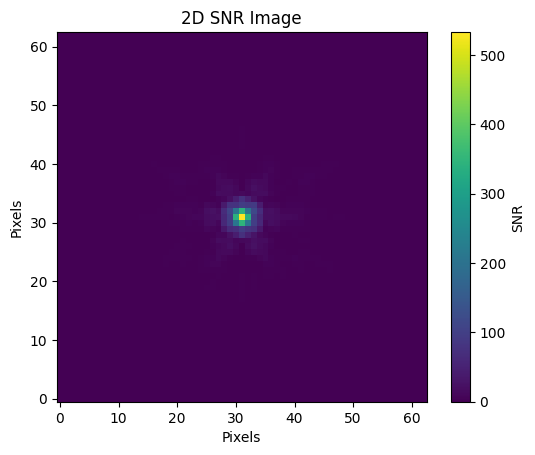

In [5]:
# Exposure information
total_exp = report['information']['exposure_specification']['total_exposure_time']  # seconds
single_exp = report['information']['exposure_specification']['exposure_time']  # seconds
single_int = single_exp / nints  #background_level seconds
print(f'Total Exposure Time: {total_exp} seconds')
print(f'Single Exposure Time: {single_exp} seconds')
print(f'Single Integration Time: {single_int} seconds') # should be less than 1000s for NIRCam to avoid cosmic rays
print('\n')

import matplotlib.pyplot as plt

# 2D SNR image
snr_2d = report['2d']['snr']
plt.imshow(snr_2d, origin='lower', cmap='viridis')
plt.colorbar(label='SNR')
plt.title('2D SNR Image')
plt.xlabel('Pixels')
plt.ylabel('Pixels')
plt.show()